In [1]:
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
from scipy.stats import pointbiserialr
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [3]:
# =========================
# 1) DATA LOADING
# =========================
df = pd.read_csv("final_cleaned_dataset.csv")

In [4]:
print("\n=========================")
print("DATA LOADED")
print("=========================")
print(df.head())
print("\nShape:", df.shape)
print("\nColumns:")
print(df.columns.tolist())


DATA LOADED
    season  year           city  fulltimehomegoals  fulltimeawaygoals  \
0  2010/11  2010     birmingham                  3                  0   
1  2010/11  2010         london                  6                  0   
2  2010/11  2010     sunderland                  2                  2   
3  2010/11  2010         london                  0                  0   
4  2010/11  2010  wolverhampton                  2                  1   

  fulltimeresult  home_win  median_salary_gross_gbp_monthly  \
0              H         1                             1972   
1              H         1                             3285   
2              D         0                             2021   
3              D         0                             3285   
4              H         1                             2121   

   cost_of_living_index  affordability_ratio  rent_to_income_pct  \
0                  67.8                 1.39                27.9   
1                  95.6          

In [5]:
# =========================
# 2) DATA OVERVIEW
# =========================
print("\n=========================")
print("DATA OVERVIEW")
print("=========================")
print(df.info())


DATA OVERVIEW
<class 'pandas.DataFrame'>
RangeIndex: 1357 entries, 0 to 1356
Data columns (total 14 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   season                           1357 non-null   str    
 1   year                             1357 non-null   int64  
 2   city                             1357 non-null   str    
 3   fulltimehomegoals                1357 non-null   int64  
 4   fulltimeawaygoals                1357 non-null   int64  
 5   fulltimeresult                   1357 non-null   str    
 6   home_win                         1357 non-null   int64  
 7   median_salary_gross_gbp_monthly  1357 non-null   int64  
 8   cost_of_living_index             1357 non-null   float64
 9   affordability_ratio              1357 non-null   float64
 10  rent_to_income_pct               1357 non-null   float64
 11  region                           1357 non-null   str    
 12  population_appro

In [6]:
print("\nMissing values:")
print(df.isnull().sum())


Missing values:
season                             0
year                               0
city                               0
fulltimehomegoals                  0
fulltimeawaygoals                  0
fulltimeresult                     0
home_win                           0
median_salary_gross_gbp_monthly    0
cost_of_living_index               0
affordability_ratio                0
rent_to_income_pct                 0
region                             0
population_approx                  0
real_wealth                        0
dtype: int64


In [7]:
print("\nDescriptive statistics:")
print(df.describe())


Descriptive statistics:
              year  fulltimehomegoals  fulltimeawaygoals     home_win  \
count  1357.000000        1357.000000        1357.000000  1357.000000   
mean   2017.456153           1.769344           1.594694     0.428150   
std       4.300875           1.519976           1.404030     0.494993   
min    2010.000000           0.000000           0.000000     0.000000   
25%    2014.000000           1.000000           0.000000     0.000000   
50%    2018.000000           2.000000           1.000000     0.000000   
75%    2021.000000           3.000000           2.000000     1.000000   
max    2024.000000           9.000000           9.000000     1.000000   

       median_salary_gross_gbp_monthly  cost_of_living_index  \
count                      1357.000000           1357.000000   
mean                       2725.235077             75.766028   
std                         655.760906             13.926752   
min                        1907.000000             56.100000 

In [8]:
# =========================
# 3) FEATURE CHECK
# =========================
wealth_cols = [
    "real_wealth",
    "affordability_ratio",
    "rent_to_income_pct"
]

In [9]:
print("\n=========================")
print("WEALTH VARIABLES")
print("=========================")
print(df[wealth_cols].describe())


WEALTH VARIABLES
       real_wealth  affordability_ratio  rent_to_income_pct
count  1357.000000          1357.000000         1357.000000
mean     35.758802             1.321614           31.402063
std       3.640937             0.094585            4.912798
min      29.085546             1.090000           21.500000
25%      33.010130             1.260000           28.000000
50%      35.237500             1.310000           29.800000
75%      37.685185             1.380000           36.200000
max      47.748148             1.680000           44.500000


In [10]:
# =========================
# 4) MATCH RESULT DISTRIBUTION
# =========================
print("\n=========================")
print("MATCH RESULT DISTRIBUTION")
print("=========================")
print(df["fulltimeresult"].value_counts())


MATCH RESULT DISTRIBUTION
fulltimeresult
H    581
A    502
D    274
Name: count, dtype: int64


In [11]:
print("\nHome win distribution:")
print(df["home_win"].value_counts())


Home win distribution:
home_win
0    776
1    581
Name: count, dtype: int64


In [12]:
overall_home_win = df["home_win"].mean()
print("\nOverall home win rate:", overall_home_win)


Overall home win rate: 0.4281503316138541


In [13]:
# =========================
# 5) CITY-LEVEL ANALYSIS
# =========================
print("\n=========================")
print("CITY-LEVEL HOME WIN RATE")
print("=========================")
city_home_win = df.groupby("city")["home_win"].mean().sort_values(ascending=False)
print(city_home_win)


CITY-LEVEL HOME WIN RATE
city
liverpool        0.543210
london           0.485955
birmingham       0.398601
leeds            0.378378
bournemouth      0.376238
wolverhampton    0.371134
brighton         0.369565
southampton      0.359155
sunderland       0.345679
blackpool        0.333333
middlesbrough    0.300000
sheffield        0.272727
reading          0.230769
Name: home_win, dtype: float64


In [14]:
print("\n=========================")
print("CITY-LEVEL HOME GOALS")
print("=========================")
city_home_goals = df.groupby("city")["fulltimehomegoals"].mean().sort_values(ascending=False)
print(city_home_goals)


CITY-LEVEL HOME GOALS
city
london           2.188202
liverpool        2.127572
blackpool        1.777778
birmingham       1.580420
brighton         1.500000
leeds            1.486486
southampton      1.485915
reading          1.461538
bournemouth      1.455446
wolverhampton    1.402062
sunderland       1.345679
sheffield        1.121212
middlesbrough    1.100000
Name: fulltimehomegoals, dtype: float64


In [15]:
# =========================
# 6) CORRELATION MATRIX
# =========================
print("\n=========================")
print("CORRELATION MATRIX")
print("=========================")


CORRELATION MATRIX


In [16]:
corr_matrix = df[
    [
        "real_wealth",
        "affordability_ratio",
        "rent_to_income_pct",
        "fulltimehomegoals",
        "fulltimeawaygoals",
        "home_win"
    ]
].corr()

In [17]:
print(corr_matrix)

                     real_wealth  affordability_ratio  rent_to_income_pct  \
real_wealth             1.000000            -0.208368            0.320813   
affordability_ratio    -0.208368             1.000000           -0.837441   
rent_to_income_pct      0.320813            -0.837441            1.000000   
fulltimehomegoals       0.034890            -0.147141            0.172921   
fulltimeawaygoals       0.067894            -0.034165            0.063917   
home_win                0.014021            -0.085178            0.080606   

                     fulltimehomegoals  fulltimeawaygoals  home_win  
real_wealth                   0.034890           0.067894  0.014021  
affordability_ratio          -0.147141          -0.034165 -0.085178  
rent_to_income_pct            0.172921           0.063917  0.080606  
fulltimehomegoals             1.000000          -0.143015  0.670452  
fulltimeawaygoals            -0.143015           1.000000 -0.517315  
home_win                      0.670452  

In [18]:
# =========================
# 7) POINT-BISERIAL CORRELATION
# =========================
print("\n=========================")
print("POINT-BISERIAL CORRELATION")
print("Socioeconomic variables vs binary home_win")
print("=========================")


POINT-BISERIAL CORRELATION
Socioeconomic variables vs binary home_win


In [19]:
for col in wealth_cols:
    corr, p_value = pointbiserialr(df["home_win"], df[col])

    print(f"\nVariable: {col}")
    print("Point-biserial correlation:", corr)
    print("P-value:", p_value)

    if p_value < 0.05:
        print("Result: Statistically significant relationship.")
    else:
        print("Result: Not statistically significant.")


Variable: real_wealth
Point-biserial correlation: 0.014020542018621417
P-value: 0.6058328604587764
Result: Not statistically significant.

Variable: affordability_ratio
Point-biserial correlation: -0.08517815780827258
P-value: 0.0016862164787296722
Result: Statistically significant relationship.

Variable: rent_to_income_pct
Point-biserial correlation: 0.08060632737896867
P-value: 0.002964127740458034
Result: Statistically significant relationship.


In [20]:
# =========================
# 8) CITY SUMMARY TABLE
# =========================
print("\n=========================")
print("CITY SUMMARY")
print("=========================")


CITY SUMMARY


In [21]:
city_summary = df.groupby("city").agg(
    matches=("home_win", "count"),
    avg_home_win=("home_win", "mean"),
    avg_home_goals=("fulltimehomegoals", "mean"),
    avg_real_wealth=("real_wealth", "mean"),
    avg_affordability=("affordability_ratio", "mean"),
    avg_rent_to_income=("rent_to_income_pct", "mean")
).sort_values(by="avg_home_win", ascending=False)

In [22]:
print(city_summary)

               matches  avg_home_win  avg_home_goals  avg_real_wealth  \
city                                                                    
liverpool          243      0.543210        2.127572        35.114728   
london             356      0.485955        2.188202        37.730955   
birmingham         143      0.398601        1.580420        33.105219   
leeds               37      0.378378        1.486486        37.277033   
bournemouth        101      0.376238        1.455446        35.450905   
wolverhampton       97      0.371134        1.402062        39.465282   
brighton            92      0.369565        1.500000        33.437033   
southampton        142      0.359155        1.485915        34.742725   
sunderland          81      0.345679        1.345679        32.926881   
blackpool            9      0.333333        1.777778        37.397504   
middlesbrough       10      0.300000        1.100000        36.056338   
sheffield           33      0.272727        1.12121

=========================
9) EDA VISUALIZATIONS
=========================

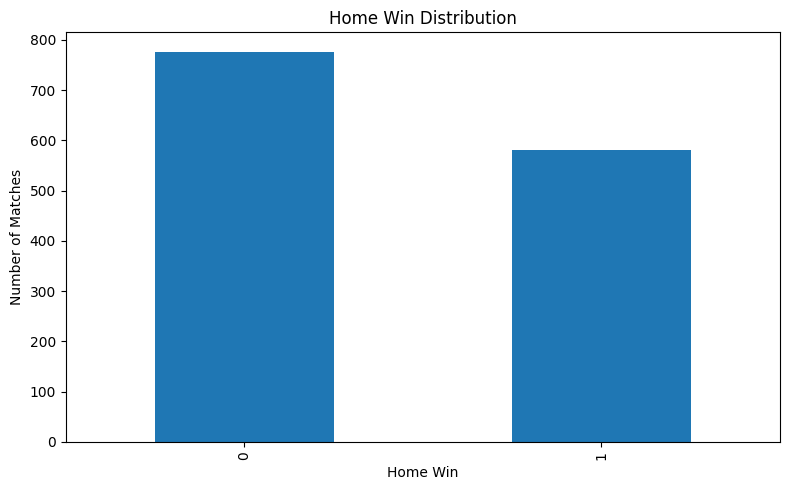

In [23]:
plt.figure(figsize=(8, 5))
df["home_win"].value_counts().sort_index().plot(kind="bar")
plt.xlabel("Home Win")
plt.ylabel("Number of Matches")
plt.title("Home Win Distribution")
plt.tight_layout()
plt.savefig("plot_home_win_distribution.png")
plt.show()

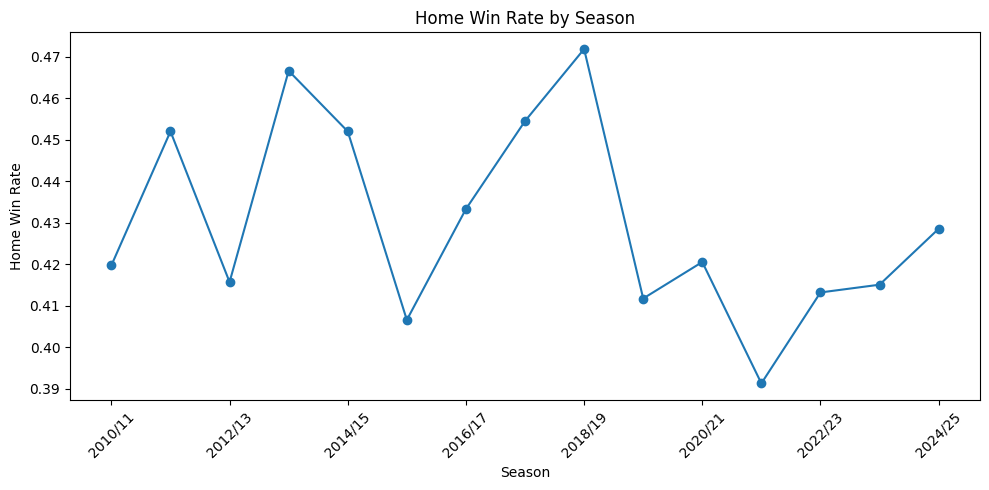

In [24]:
plt.figure(figsize=(10, 5))
df.groupby("season")["home_win"].mean().plot(marker="o")
plt.xlabel("Season")
plt.ylabel("Home Win Rate")
plt.title("Home Win Rate by Season")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig("plot_home_win_rate_by_season.png")
plt.show()

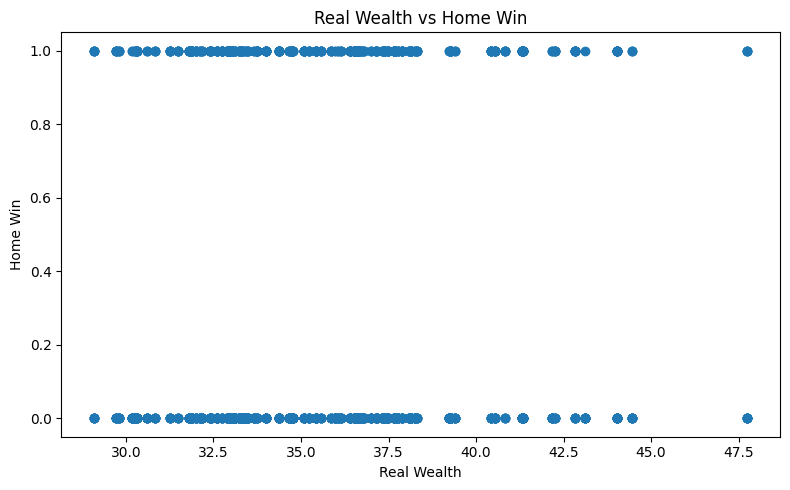

In [25]:
plt.figure(figsize=(8, 5))
plt.scatter(df["real_wealth"], df["home_win"])
plt.xlabel("Real Wealth")
plt.ylabel("Home Win")
plt.title("Real Wealth vs Home Win")
plt.tight_layout()
plt.savefig("plot_real_wealth_vs_home_win.png")
plt.show()

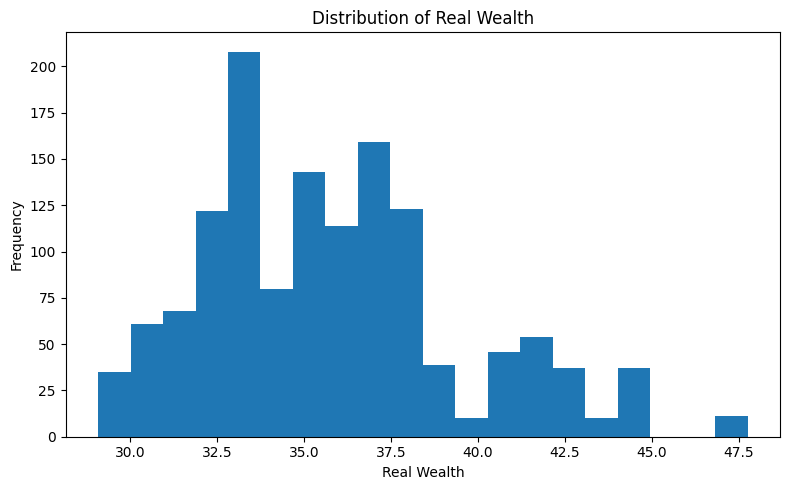

In [26]:
plt.figure(figsize=(8, 5))
plt.hist(df["real_wealth"], bins=20)
plt.xlabel("Real Wealth")
plt.ylabel("Frequency")
plt.title("Distribution of Real Wealth")
plt.tight_layout()
plt.savefig("plot_real_wealth_distribution.png")
plt.show()

<Figure size 800x500 with 0 Axes>

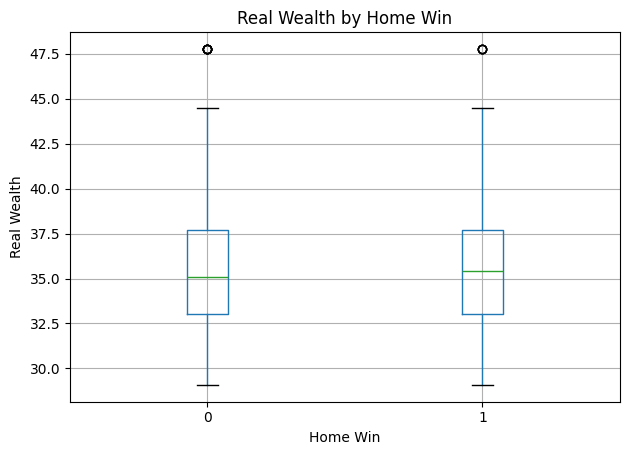

In [27]:
plt.figure(figsize=(8, 5))
df.boxplot(column="real_wealth", by="home_win")
plt.xlabel("Home Win")
plt.ylabel("Real Wealth")
plt.title("Real Wealth by Home Win")
plt.suptitle("")
plt.tight_layout()
plt.savefig("plot_real_wealth_by_home_win.png")
plt.show()

<Figure size 800x500 with 0 Axes>

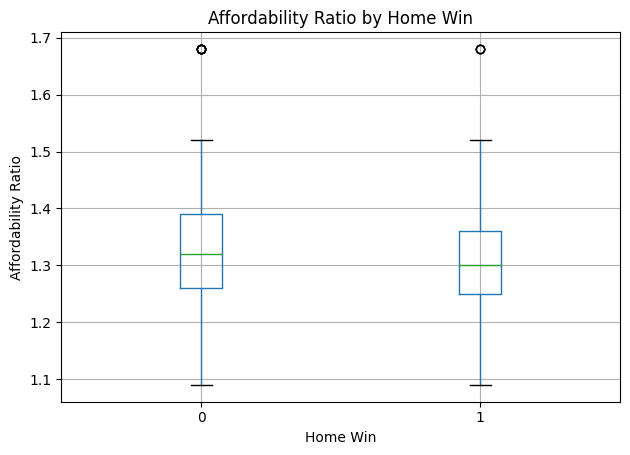

In [28]:
plt.figure(figsize=(8, 5))
df.boxplot(column="affordability_ratio", by="home_win")
plt.xlabel("Home Win")
plt.ylabel("Affordability Ratio")
plt.title("Affordability Ratio by Home Win")
plt.suptitle("")
plt.tight_layout()
plt.savefig("plot_affordability_by_home_win.png")
plt.show()

<Figure size 800x500 with 0 Axes>

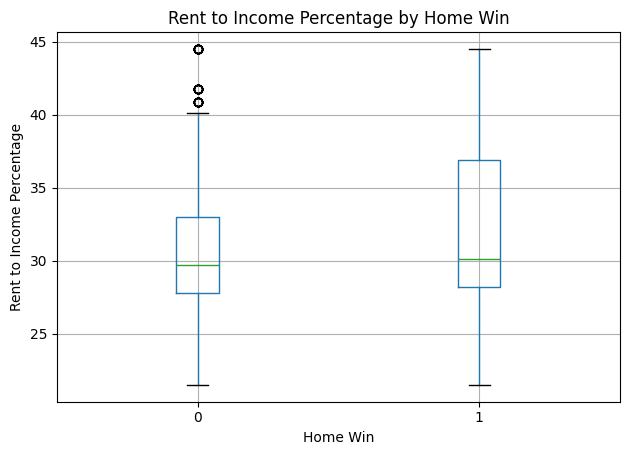

In [29]:
plt.figure(figsize=(8, 5))
df.boxplot(column="rent_to_income_pct", by="home_win")
plt.xlabel("Home Win")
plt.ylabel("Rent to Income Percentage")
plt.title("Rent to Income Percentage by Home Win")
plt.suptitle("")
plt.tight_layout()
plt.savefig("plot_rent_to_income_by_home_win.png")
plt.show()

In [30]:
# =========================
# 10) MACHINE LEARNING MODELS
# =========================
print("\n=========================")
print("MACHINE LEARNING MODELS")
print("=========================")


MACHINE LEARNING MODELS


In [31]:
features = [
    "real_wealth",
    "affordability_ratio",
    "rent_to_income_pct"
]

In [32]:
model_data = df[features + ["home_win"]].dropna()

In [33]:
X = model_data[features]
y = model_data["home_win"]

In [34]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [35]:
# Logistic Regression
log_model = LogisticRegression(max_iter=1000)
log_model.fit(X_train, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [36]:
y_pred_log = log_model.predict(X_test)

In [37]:
print("\nLOGISTIC REGRESSION RESULTS")
print("Accuracy:", accuracy_score(y_test, y_pred_log))
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_log))
print("Classification Report:")
print(classification_report(y_test, y_pred_log, zero_division=0))


LOGISTIC REGRESSION RESULTS
Accuracy: 0.5551470588235294
Confusion Matrix:
[[140  20]
 [101  11]]
Classification Report:
              precision    recall  f1-score   support

           0       0.58      0.88      0.70       160
           1       0.35      0.10      0.15       112

    accuracy                           0.56       272
   macro avg       0.47      0.49      0.43       272
weighted avg       0.49      0.56      0.47       272



In [38]:
log_coefficients = pd.DataFrame({
    "Feature": features,
    "Coefficient": log_model.coef_[0]
})

In [39]:
print("\nLogistic Regression Coefficients:")
print(log_coefficients)


Logistic Regression Coefficients:
               Feature  Coefficient
0          real_wealth    -0.003882
1  affordability_ratio    -0.341850
2   rent_to_income_pct     0.037036


In [40]:
# Random Forest
rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

In [41]:
rf_model.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [42]:
y_pred_rf = rf_model.predict(X_test)

In [43]:
print("\nRANDOM FOREST RESULTS")
print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_rf))
print("Classification Report:")
print(classification_report(y_test, y_pred_rf, zero_division=0))


RANDOM FOREST RESULTS
Accuracy: 0.5220588235294118
Confusion Matrix:
[[105  55]
 [ 75  37]]
Classification Report:
              precision    recall  f1-score   support

           0       0.58      0.66      0.62       160
           1       0.40      0.33      0.36       112

    accuracy                           0.52       272
   macro avg       0.49      0.49      0.49       272
weighted avg       0.51      0.52      0.51       272



In [44]:
feature_importance = pd.DataFrame({
    "Feature": features,
    "Importance": rf_model.feature_importances_
}).sort_values(by="Importance", ascending=False)

In [45]:
print("\nRandom Forest Feature Importance:")
print(feature_importance)


Random Forest Feature Importance:
               Feature  Importance
0          real_wealth    0.387347
2   rent_to_income_pct    0.339626
1  affordability_ratio    0.273027


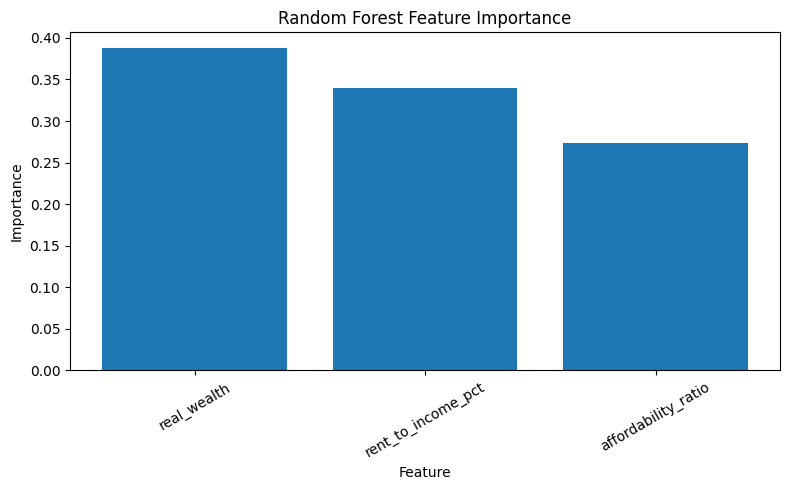

In [46]:
plt.figure(figsize=(8, 5))
plt.bar(feature_importance["Feature"], feature_importance["Importance"])
plt.xlabel("Feature")
plt.ylabel("Importance")
plt.title("Random Forest Feature Importance")
plt.xticks(rotation=30)
plt.tight_layout()
plt.savefig("plot_random_forest_feature_importance.png")
plt.show()

In [47]:
# =========================
# 11) OUTPUT FILES
# =========================
city_summary.to_csv("city_summary.csv")

In [48]:
print("\n=========================")
print("FILES CREATED")
print("=========================")
print("1) plot_home_win_distribution.png")
print("2) plot_home_win_rate_by_season.png")
print("3) plot_real_wealth_vs_home_win.png")
print("4) plot_real_wealth_distribution.png")
print("5) plot_real_wealth_by_home_win.png")
print("6) plot_affordability_by_home_win.png")
print("7) plot_rent_to_income_by_home_win.png")
print("8) plot_random_forest_feature_importance.png")
print("9) city_summary.csv")


FILES CREATED
1) plot_home_win_distribution.png
2) plot_home_win_rate_by_season.png
3) plot_real_wealth_vs_home_win.png
4) plot_real_wealth_distribution.png
5) plot_real_wealth_by_home_win.png
6) plot_affordability_by_home_win.png
7) plot_rent_to_income_by_home_win.png
8) plot_random_forest_feature_importance.png
9) city_summary.csv


In [49]:
# =========================
# 12) INTERPRETATION
# =========================
print("\n=========================")
print("INTERPRETATION")
print("=========================")


INTERPRETATION


In [50]:
print(
    "Point-biserial correlation is used because home_win is a binary variable. "
    "This is more appropriate than Pearson correlation for testing the relationship "
    "between a binary outcome and continuous socioeconomic variables."
)

Point-biserial correlation is used because home_win is a binary variable. This is more appropriate than Pearson correlation for testing the relationship between a binary outcome and continuous socioeconomic variables.


In [51]:
print(
    "The machine learning models use socioeconomic indicators to predict whether "
    "the home team wins. Logistic Regression provides a simple baseline model, "
    "while Random Forest can capture more complex non-linear patterns."
)

The machine learning models use socioeconomic indicators to predict whether the home team wins. Logistic Regression provides a simple baseline model, while Random Forest can capture more complex non-linear patterns.


In [52]:
print(
    "If the correlations are weak and model accuracy is limited, this suggests that "
    "socioeconomic variables alone are not strong predictors of football match outcomes. "
    "Football results are also affected by team quality, injuries, tactics, player form, "
    "and other sporting factors."
)

If the correlations are weak and model accuracy is limited, this suggests that socioeconomic variables alone are not strong predictors of football match outcomes. Football results are also affected by team quality, injuries, tactics, player form, and other sporting factors.
